In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_parquet("out/output.parquet")
%matplotlib widget

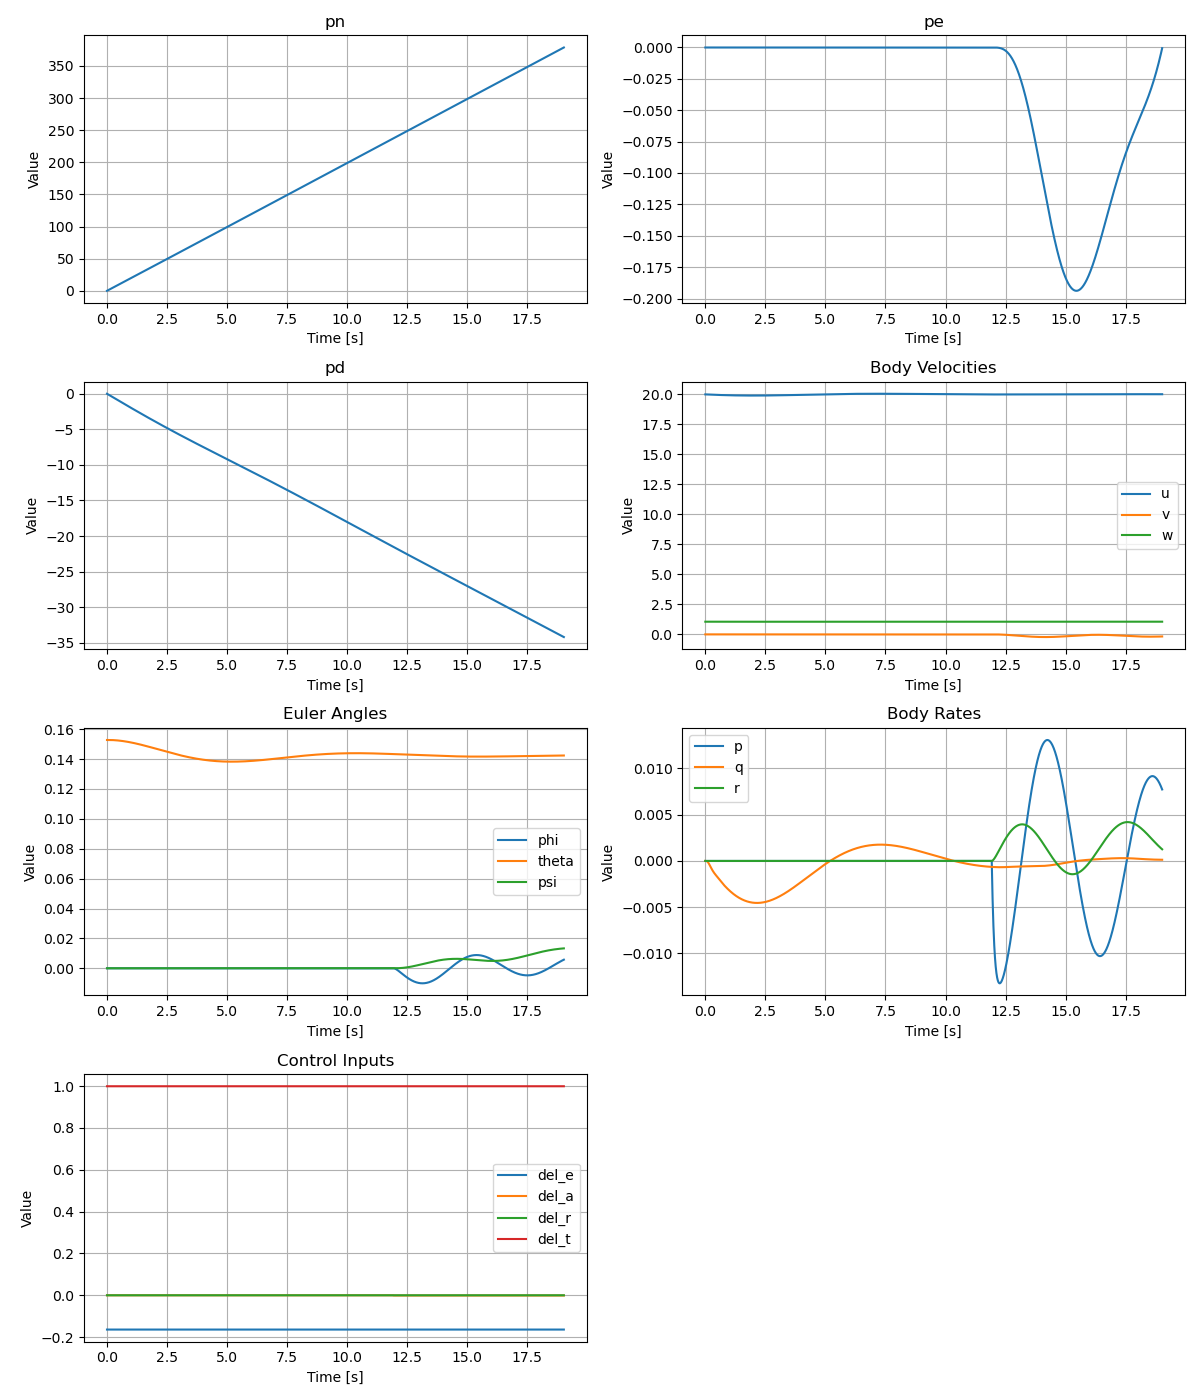

In [3]:
import math
import matplotlib.pyplot as plt

t = df["t"]

plot_groups = [
    (["pn"], "pn"),
    (["pe"], "pe"),
    (["pd"], "pd"),
    (["u", "v", "w"], "Body Velocities"),
    (["phi", "theta", "psi"], "Euler Angles"),
    (["p", "q", "r"], "Body Rates"),
    (["del_e", "del_a", "del_r", "del_t"], "Control Inputs"),
]

ncols = 2
nrows = math.ceil(len(plot_groups) / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), squeeze=False)
ax = ax.flatten()

for i, (cols, title) in enumerate(plot_groups):
    for col in cols:
        if col in df.columns:
            ax[i].plot(t, df[col], label=col)
    ax[i].set_title(title)
    ax[i].set_xlabel("Time [s]")
    ax[i].set_ylabel("Value")
    ax[i].grid(True)
    if len(cols) > 1:
        ax[i].legend()

# Hide any unused axes
for j in range(len(plot_groups), len(ax)):
    ax[j].axis("off")

fig.tight_layout()
plt.show()